# CPU Benchmark Analysis — Feature Engineering and Modeling

This notebook takes the cleaned dataset produced in Notebook 2 and prepares it
for machine learning. We engineer new features, encode categorical columns, and
train three regression models of increasing complexity to predict cpuMark.

The three models we compare are:
- Linear Regression — a simple baseline
- Random Forest — handles non-linear relationships
- XGBoost — sequential tree boosting, generally best for tabular data

Model selection is based on R² and RMSE evaluated on a held-out test set.

In [1]:
# Mount Google Drive and load the cleaned dataset

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

path = '/content/drive/MyDrive/CPU Project/'
df = pd.read_csv(path + 'CPU_benchmark_cleaned.csv')

print("Cleaned dataset loaded successfully")
print(f"Shape: {df.shape}")

Mounted at /content/drive
Cleaned dataset loaded successfully
Shape: (3825, 9)


-------

## Step 1 — Feature Engineering

Feature engineering is the process of creating new columns that help the model
better understand the relationship between specs and cpuMark. Rather than just
feeding in raw columns, we create features that capture more meaningful patterns.

We create three new features based on domain knowledge of CPU hardware.

In [2]:
# Create new features based on CPU hardware domain knowledge

df['price_per_core'] = df['price'] / df['cores']
df['tdp_per_core'] = df['TDP'] / df['cores']
df['thread_to_core_ratio'] = df['threadMark'] / df['cores']

print("New features created successfully")
print()
print("Sample values:")
print(df[['price_per_core', 'tdp_per_core', 'thread_to_core_ratio']].head())

New features created successfully

Sample values:
   price_per_core  tdp_per_core  thread_to_core_ratio
0        1.807344      4.375000             52.031250
1      114.062344      4.375000             41.171875
2        5.295078      0.828125             37.296875
3      110.312500      3.515625             42.609375
4      106.374687      4.375000             41.031250


### New Features

`price_per_core` — price divided by number of cores. This captures how much
each core costs, which reflects the CPU's market positioning more precisely
than price alone.

`tdp_per_core` — TDP divided by number of cores. This measures how much power
each core consumes, which is a proxy for core efficiency.

`thread_to_core_ratio` — threadMark divided by cores. This captures single
thread efficiency relative to the number of cores, which varies significantly
between CPU architectures.

-----

## Step 2 — Log Transform the Target Variable

As identified in Notebook 1, cpuMark is heavily right skewed. We apply a log
transformation before modeling to make the distribution more symmetrical.
This helps all three models learn more effectively.

We use log1p which computes log(1 + x) instead of log(x). This is a safe
choice because it handles zero values without returning negative infinity,
even though cpuMark has no zeros in our dataset.

When we evaluate predictions we reverse this transformation using np.expm1
to get back to the original cpuMark scale.

In [3]:
# Apply log transformation to the target variable

df['cpuMark_log'] = np.log1p(df['cpuMark'])

print("cpuMark stats before transformation:")
print(f"Mean: {df['cpuMark'].mean():.2f}  Std: {df['cpuMark'].std():.2f}")
print()
print("cpuMark stats after log transformation:")
print(f"Mean: {df['cpuMark_log'].mean():.2f}  Std: {df['cpuMark_log'].std():.2f}")

cpuMark stats before transformation:
Mean: 5992.31  Std: 9617.55

cpuMark stats after log transformation:
Mean: 7.81  Std: 1.38


### Log Transformation Result

Before transformation the standard deviation was 9,617 — meaning predictions
could easily be off by thousands of points just from natural variance in the data.
After transformation the standard deviation is only 1.38 on the log scale.

This confirms the transformation is working as intended. All models will be
trained on cpuMark_log and predictions will be converted back to the original
scale using np.expm1 for evaluation.

-----

## Step 3 — Encode Categorical Columns

Machine learning models cannot work with text directly. We need to convert
category and socket into numeric form.

We use one-hot encoding which creates a new binary column for each unique value.
For example category becomes four columns — category_Desktop, category_Laptop,
category_Server and category_Other — where each row has a 1 in the column that
applies to it and 0 everywhere else.

We drop the first column from each encoded group to avoid multicollinearity,
which is a situation where one column can be perfectly predicted from the others.

In [4]:
# One-hot encode the categorical columns
# drop_first=True drops one column per group to avoid multicollinearity

df_encoded = pd.get_dummies(df, columns=['category', 'socket'], drop_first=True)

print(f"Shape before encoding: {df.shape}")
print(f"Shape after encoding : {df_encoded.shape}")

Shape before encoding: (3825, 13)
Shape after encoding : (3825, 83)


### Encoding Result

One-hot encoding expanded the dataset from 13 to 83 columns. The majority of
new columns come from the socket column which had 70 unique values. This is
expected and not a problem — tree based models like Random Forest and XGBoost
handle high dimensional data well. Linear Regression may struggle slightly
with this many columns but it will still serve as a useful baseline.

-----

## Step 4 — Define Features and Target, Split the Data

We now define which columns are our input features and which is our target.
We then split the data into a training set and a test set.

The test set is data the model never sees during training. We use it at the
end to evaluate how well the model generalizes to unseen CPUs. We use an
80/20 split — 80% for training and 20% for testing.

In [5]:
from sklearn.model_selection import train_test_split

# Define features and target
# We drop cpuName, cpuMark and cpuMark_log from features
# cpuName is an identifier, cpuMark is the raw target, cpuMark_log is what we predict

X = df_encoded.drop(columns=['cpuName', 'cpuMark', 'cpuMark_log'])
y = df_encoded['cpuMark_log']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size : {X_train.shape[0]} rows")
print(f"Test set size     : {X_test.shape[0]} rows")
print(f"Number of features: {X_train.shape[1]}")

Training set size : 3060 rows
Test set size     : 765 rows
Number of features: 80


-----

## Step 5 — Train and Evaluate Models

We train three models in order of increasing complexity. For each model we report
two metrics evaluated on the held-out test set:

R² — measures how much of the variance in cpuMark our model explains.
A score of 1.0 is perfect, 0.0 means the model is no better than predicting
the mean every time.

RMSE — Root Mean Squared Error, measured in the original cpuMark scale after
reversing the log transformation. This tells us on average how far off our
predictions are in real benchmark points.

---

### Model 1 — Linear Regression

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on test set
y_pred_lr = lr.predict(X_test)

# Evaluate on original scale by reversing the log transformation
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(
    np.expm1(y_test),
    np.expm1(y_pred_lr)
))

print("Linear Regression")
print(f"R²   : {r2_lr:.4f}")
print(f"RMSE : {rmse_lr:.2f} benchmark points")

Linear Regression
R²   : 0.9424
RMSE : 16530.06 benchmark points


### Model 1 Results — Linear Regression

Linear Regression achieves an R² of 0.9424, meaning it explains 94% of the
variance in cpuMark using only hardware specs. This is a strong baseline and
suggests the relationship between specs and benchmark scores is largely linear.

However the RMSE of 16,530 benchmark points indicates the model struggles with
extreme values at the high end of the scale — server and workstation CPUs with
very high scores. We expect the tree based models to handle these better.

-----

### Model 2 — Random Forest

In [7]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest
# n_estimators=100 means we build 100 trees
# random_state=42 ensures reproducibility

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf.predict(X_test)

# Evaluate on original scale
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(
    np.expm1(y_test),
    np.expm1(y_pred_rf)
))

print("Random Forest")
print(f"R²   : {r2_rf:.4f}")
print(f"RMSE : {rmse_rf:.2f} benchmark points")

Random Forest
R²   : 0.9809
RMSE : 2339.83 benchmark points


### Model 2 Results — Random Forest

Random Forest improves R² to 0.9809 and dramatically reduces RMSE from 16,530
down to 2,339 benchmark points — a 7x improvement over the baseline. This confirms
that while the overall relationship between specs and cpuMark is largely linear,
there are meaningful non-linear patterns that tree based models capture much better.

The improvement in RMSE suggests Random Forest is handling the extreme high end
server and workstation CPUs far more accurately than Linear Regression.

---

### Model 3 — XGBoost

In [8]:
from xgboost import XGBRegressor

# Train XGBoost
# n_estimators=100 — number of trees
# learning_rate=0.1 — how much each tree corrects the previous one
# random_state=42 ensures reproducibility

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

# Predict on test set
y_pred_xgb = xgb.predict(X_test)

# Evaluate on original scale
r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(
    np.expm1(y_test),
    np.expm1(y_pred_xgb)
))

print("XGBoost")
print(f"R²   : {r2_xgb:.4f}")
print(f"RMSE : {rmse_xgb:.2f} benchmark points")

XGBoost
R²   : 0.9833
RMSE : 2331.22 benchmark points


### Model 3 Results — XGBoost

XGBoost achieves an R² of 0.9833 and an RMSE of 2,331 benchmark points — a marginal
improvement over Random Forest. The gap between the two tree based models is small,
suggesting the dataset is clean and structured enough that Random Forest already
captures most of the available signal.

XGBoost is selected as the final model based on its slightly superior performance
on both metrics.

----

## Step 6 — Model Comparison

In [9]:
# Compare all three models side by side

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'R²': [r2_lr, r2_rf, r2_xgb],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb]
})

results['R²'] = results['R²'].round(4)
results['RMSE'] = results['RMSE'].round(2)

print("Model Comparison")
print()
print(results.to_string(index=False))

Model Comparison

            Model     R²     RMSE
Linear Regression 0.9424 16530.06
    Random Forest 0.9809  2339.83
          XGBoost 0.9833  2331.22


### Model Comparison Summary

All three models achieve strong R² scores above 0.94, confirming that CPU hardware
specs are highly predictive of benchmark performance. However the RMSE tells a more
nuanced story.

Linear Regression achieves a strong R² of 0.9424 but struggles with an RMSE of
16,530 benchmark points — meaning its predictions can be off by a significant margin
on high end CPUs. Both tree based models reduce this error dramatically, with Random
Forest and XGBoost achieving RMSE values of 2,339 and 2,331 respectively — roughly
a 7x improvement over the baseline.

The marginal difference between Random Forest and XGBoost suggests the dataset is
clean and well structured enough that both models capture most of the available signal.
XGBoost is selected as the final model based on its slightly superior performance
on both metrics.

-------

## Step 7 — Feature Importance with SHAP

SHAP (SHapley Additive Explanations) tells us how much each feature contributes
to the model's predictions. Unlike simply looking at feature importance scores,
SHAP shows the direction and magnitude of each feature's impact — whether a higher
value pushes the prediction up or down and by how much.

This is one of the most valuable parts of the project because it answers the
question that matters most — which CPU specs actually drive benchmark performance?

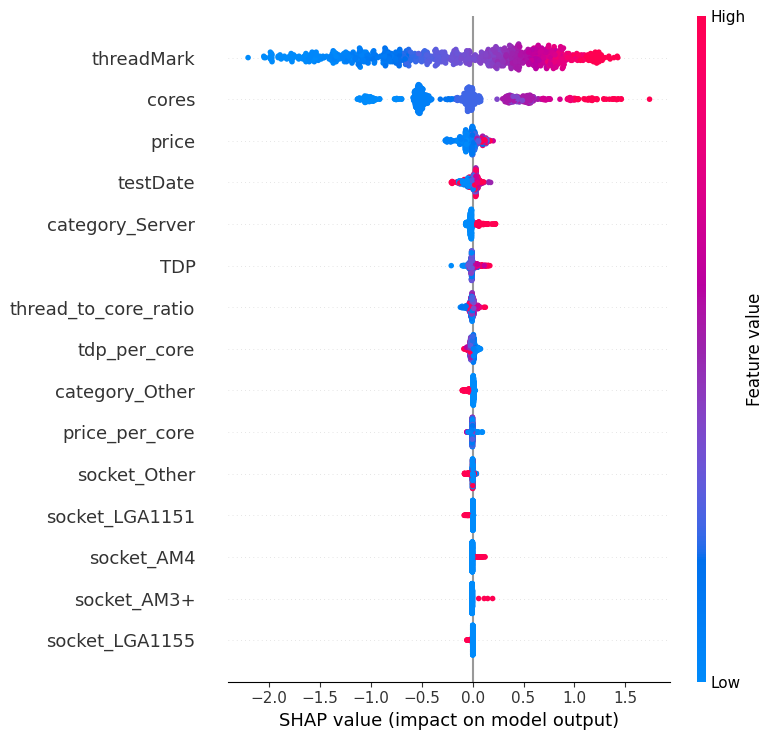

In [11]:
!pip install shap --quiet

import shap

# Convert to float to ensure SHAP can process all columns correctly
X_train_float = X_train.astype(float)
X_test_float = X_test.astype(float)

# Retrain XGBoost on the float version to ensure consistency
xgb.fit(X_train_float, y_train)

# Compute SHAP values
explainer = shap.Explainer(xgb, X_train_float)
shap_values = explainer(X_test_float)

# Summary plot — shows the most important features and their impact direction
shap.summary_plot(shap_values, X_test_float, max_display=15)

## SHAP Feature Importance

The SHAP summary plot reveals which features drive cpuMark predictions the most
and in which direction.

threadMark is the dominant feature by a significant margin. High single thread
performance strongly pushes the predicted cpuMark upward, which makes sense given
that single thread efficiency is a core driver of overall CPU performance.

cores is the second most influential feature. More cores consistently increases
the predicted cpuMark, reflecting the multi-thread nature of the benchmark.

price and testDate have moderate positive effects — more expensive and more recent
CPUs tend to score higher, capturing market positioning and generational improvements
in architecture respectively.

The engineered features tdp_per_core, thread_to_core_ratio, and price_per_core
all appear in the top 15, confirming that feature engineering added value beyond
the raw columns alone.

Socket type has minimal predictive power, appearing at the bottom with near zero
SHAP values. This suggests that once we account for cores, threadMark, and price,
the socket type adds little additional information.

------

## Summary

This notebook completed the full modeling pipeline for predicting CPU benchmark scores.

Feature engineering created three new meaningful columns — price_per_core,
tdp_per_core, and thread_to_core_ratio — all of which appeared in the top 15
most important features according to SHAP.

The log transformation of cpuMark was essential — it reduced the standard deviation
from 9,617 to 1.38 and allowed all three models to learn more effectively.

Among the three models tested, XGBoost performed best with an R² of 0.9833 and
an RMSE of 2,331 benchmark points. The biggest performance gain came from moving
from Linear Regression to tree based models, confirming that while the relationship
between specs and cpuMark is largely linear, meaningful non-linear patterns exist
especially at the high end of the benchmark scale.

SHAP analysis confirmed that threadMark and cores are the two most influential
predictors of CPU benchmark performance.

In [12]:
import joblib
import json

# Save the trained XGBoost model
joblib.dump(xgb, path + 'xgb_model.pkl')

# Save the feature column names and order
feature_columns = X_train_float.columns.tolist()
with open(path + 'feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)

print("Model saved successfully")
print(f"Features saved: {len(feature_columns)} columns")

Model saved successfully
Features saved: 80 columns


# Streamlit App

In [13]:
app_code = '''import streamlit as st
import pandas as pd
import numpy as np
import joblib
import json

# Load the model and feature columns
model = joblib.load("xgb_model.pkl")

with open("feature_columns.json", "r") as f:
    feature_columns = json.load(f)

# App title
st.title("CPU Benchmark Score Predictor")
st.write("Enter a CPU s hardware specifications to get an estimated PassMark multi-thread benchmark score.")

# Input fields
st.header("CPU Specifications")

cores = st.number_input("Number of Cores", min_value=1, max_value=256, value=8)
threadMark = st.number_input("Single Thread Mark", min_value=0, max_value=5000, value=2000)
price = st.number_input("Price (USD)", min_value=0.0, max_value=10000.0, value=300.0)
TDP = st.number_input("TDP (Watts)", min_value=1, max_value=400, value=65)
testDate = st.number_input("Release Year", min_value=2000, max_value=2024, value=2022)
category = st.selectbox("Category", ["Desktop", "Laptop", "Server", "Other"])

# Predict button
if st.button("Predict cpuMark"):

    # Compute engineered features
    price_per_core = price / cores
    tdp_per_core = TDP / cores
    thread_to_core_ratio = threadMark / cores

    # Build input row with all zeros matching training columns
    input_dict = {col: 0 for col in feature_columns}

    # Fill in known values
    input_dict["cores"] = cores
    input_dict["threadMark"] = threadMark
    input_dict["price"] = price
    input_dict["TDP"] = TDP
    input_dict["testDate"] = testDate
    input_dict["price_per_core"] = price_per_core
    input_dict["tdp_per_core"] = tdp_per_core
    input_dict["thread_to_core_ratio"] = thread_to_core_ratio

    # Set the correct category column
    if category == "Server":
        input_dict["category_Server"] = 1
    elif category == "Laptop":
        input_dict["category_Laptop"] = 1
    elif category == "Other":
        input_dict["category_Other"] = 1
    # Desktop is the base category — all zeros

    # Convert to dataframe and predict
    input_df = pd.DataFrame([input_dict]).astype(float)
    prediction_log = model.predict(input_df)[0]
    prediction = np.expm1(prediction_log)

    # Display result
    st.success(f"Estimated cpuMark Score: {int(prediction):,}")
    st.caption("This is an estimate based on the XGBoost model trained on PassMark benchmark data.")
'''

# Save app.py to the app folder in Google Drive
with open(path + 'app/app.py', 'w') as f:
    f.write(app_code)

print("app.py saved successfully")

app.py saved successfully


In [14]:
requirements = '''streamlit
pandas
numpy
joblib
xgboost
'''

# Save requirements.txt to the app folder
with open(path + 'app/requirements.txt', 'w') as f:
    f.write(requirements)

print("requirements.txt saved successfully")

requirements.txt saved successfully


In [16]:
import shutil
import os

# Copy the model and feature columns into the app folder
shutil.copy(path + 'xgb_model.pkl', path + 'app/xgb_model.pkl')
shutil.copy(path + 'feature_columns.json', path + 'app/feature_columns.json')

print("Files copied successfully")
print("App folder contents:")
print(os.listdir(path + 'app/'))

Files copied successfully
App folder contents:
['app.py', 'requirements.txt', 'xgb_model.pkl', 'feature_columns.json']
